In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    number1: int 
    operation: str 
    number2: int
    number3 :int
    operation2 :str
    number4 : int
    finalNumber: int
    finalNumber2 : int

In [4]:
def adder(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]

    return state

def subtractor(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def adder2(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber"] = state["number3"] + state["number4"]

    return state

def subtractor2(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber"] = state["number3"] - state["number4"]
    return state


def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation"] == "+":
        return "addition_operation"
    
    elif state["operation"] == "-":
        return "subtraction_operation" 

def decide_next_node2(state:AgentState) -> AgentState:
    """This node will select the next node of the next graph"""

    if state["operation2"] == "+":
        return "addition_operation2"
    
    elif state["operation2"] == "-":
        return "subtraction_operation2"

In [5]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("sub_node", subtractor)
graph.add_node("router", lambda state:state) # passthrough function -> because we are not returning a state here ,so we are passthroughing input as putput

graph.add_node("router2",lambda state :state)
graph.add_node("add_node2", adder)
graph.add_node("sub_node2", subtractor)

graph.add_edge(START, "router") 
graph.add_conditional_edges("router", decide_next_node ,
                            { 
                                "addition_operation" : "add_node",
                                "subtraction_operation" : "sub_node"
                            }
                           )

graph.add_edge("add_node", "router2")
graph.add_edge("sub_node","router2")

graph.add_conditional_edges('router2',decide_next_node2,
              {
                  "addition_operation2" : "add_node2",
                  "subtraction_operation2" : "sub_node2"
              })
graph.add_edge("add_node2",END)
graph.add_edge("sub_node2",END)

app = graph.compile()

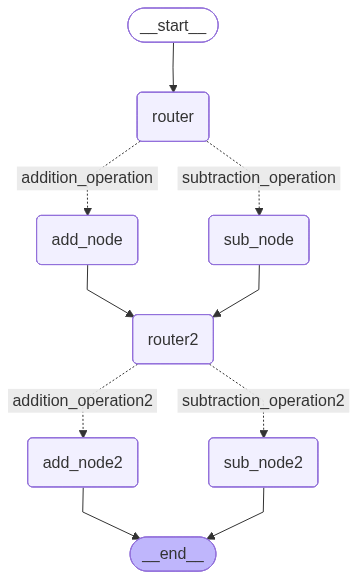

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
result = AgentState(number1 = 10, operation="-", number2 = 5, number3 = 7, number4=2, operation2="+", finalNumber= 0, finalNumber2 = 0)

In [8]:
result

{'number1': 10,
 'operation': '-',
 'number2': 5,
 'number3': 7,
 'number4': 2,
 'operation2': '+',
 'finalNumber': 0,
 'finalNumber2': 0}